# Clustering Problemleri & K-Means Algoritması

Bu çalışmada, bir unsupervised learning algoritması olan **K-Means'in** nasıl kullanılacağını öğrenmektir. Bu algoritmayı sklearn kullanarak nasıl çalıştıracağımızı göreceğiz.

Bu dersin sonunda şunları yapabiliyor olmayı hedefliyoruz:

1. K-Means algoritmasında çalışmak
2. K-Means algoritmasının parametrelerini en iyi şekilde nasıl belirleyeceğimizi anlamak
3. Inertia değerini, optimum cluster sayısını belirlemekte nasıl kullanacağımızı öğrenmek

## 1. Notebook'da Kullanılacak Ayarları Tanımlama 

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import scale
from sklearn.cluster import KMeans
from sklearn.datasets import make_blobs
from sklearn.utils import shuffle
from sklearn.datasets import fetch_openml

In [2]:
plt.rcParams['figure.figsize'] = [6,6]
sns.set_style("whitegrid")
sns.set_context("talk")

## 2. Kullanılacak Veri Setini Oluşturma

In [3]:
# Çalışmalarımızda kullanacağımız basit bir veri seti oluşturma
def display_cluster(X, km=[], num_clusters=0):
    color = 'brgcmyk'
    alpha = 0.5
    s = 20
    if num_clusters == 0:
        plt.scatter(X[:,0], X[:,1], c = color[0], alpha = alpha, s = s)
    else:
        for i in range(num_clusters):
            plt.scatter(X[km.labels_==i,0], X[km.labels_==i,1], c = color[i], alpha = alpha, s=s)
            plt.scatter(km.cluster_centers_[i][0],km.cluster_centers_[i][1], c = color[i], marker = 'x', s = 100)

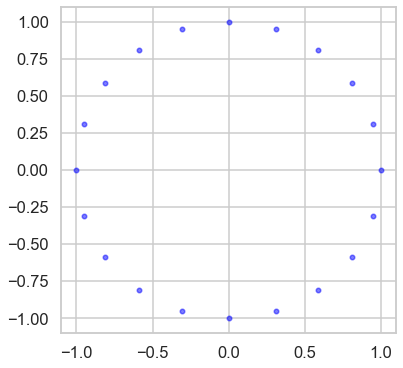

In [4]:
angle = np.linspace(0,2*np.pi,20, endpoint = False)
X = np.append([np.cos(angle)],[np.sin(angle)],0).transpose()
display_cluster(X)

Yukarıdaki şekilde gördüğümüz gibi elimizde oldukça düzenli dağılan bir veri kümesi var.

> **SORU:** Sizden bu verileri 2 clustera bölmenizi istesek bu bölme işlemini nasıl gerçekleştirirdiniz?

Oluşturduğumuz veriler oldukça dengeli dağıldıkları için muhtemelen bu soruya net bir cevap veremediniz. Peki böyle bir durumla karşılaştığında bakalım K-Means algoritması nasıl bir yol izleyecek?

Eğer hatırlıyorsanız K-Means'i ilk konuşmaya başladığımızda, cluster ayrımını yapabilmesi için **elde etmek istediğimiz cluster sayısı kadar rastgele belirlenen merkez noktalarına** ihtiyaç duyuyordu. İşte burada K-Means algoritması içinde tanımladığımız `random_state` parametresi bizim için tam olarak bu başlangıç noktasına karar veriyor.

Şimdi de, `random_state` parametresini ilk olarak 10 olarak tanımladığımızda karşımıza nasıl bir sonuç geldiğini inceleyelim.

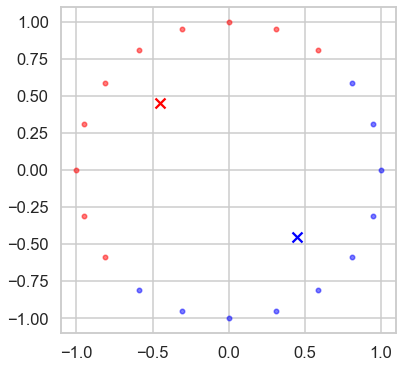

In [5]:
num_clusters = 2 # Oluşturmak istediğimiz cluster sayısı
km = KMeans(n_clusters=num_clusters, random_state=10)
km.fit(X)
display_cluster(X, km, num_clusters)

Ya `random_state` parametresini 20 olarak değiştirirsem?

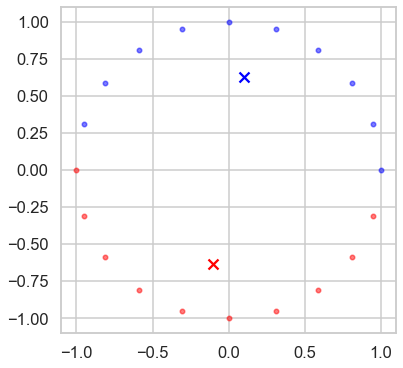

In [6]:
km = KMeans(n_clusters=num_clusters, random_state=20)
km.fit(X)
display_cluster(X, km, num_clusters)

Aynı sunum dosyamızda konuştuğumuz gibi, başlangıç noktaları her farklı seçildiğinde veri kaynağımız aynı olmasına rağmen karşımıza hep **farklı cluster ayrımları** çıkıyor. Ama neyse ki biz böyle durumlarda nasıl yaklaşım bir tarzı izleyeceğimizi konuşmuştuk.

Hadi bu konuştuklarımızı da uygulamaya geçirelim.

## 3. Optimum Cluster Sayısını Belirleme

İşleri biraz daha zorlaştırmak için daha karmaşık bir veri seti daha oluşturalım.

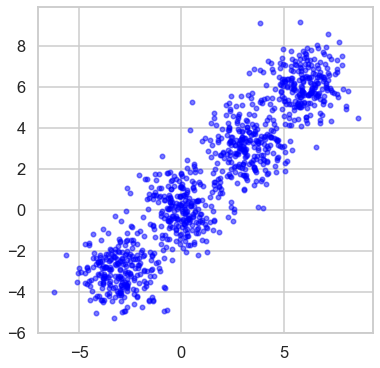

In [7]:
n_samples = 1000 # 1000 veri noktamız olsun
n_bins = 4  
centers = [(-3, -3), (0, 0), (3, 3), (6, 6)]
X, y = make_blobs(n_samples=n_samples, n_features=2, cluster_std=1.0,
                  centers=centers, shuffle=False, random_state=42)
display_cluster(X)

> **SORU:** Yukarıdaki şekle baktığınızda sizce en uygun cluster sayısı kaç olmalı?

4 cluster bu veri setimize uygun bir seçenek gibi duruyor. O zaman hadi bunu deneyelim.

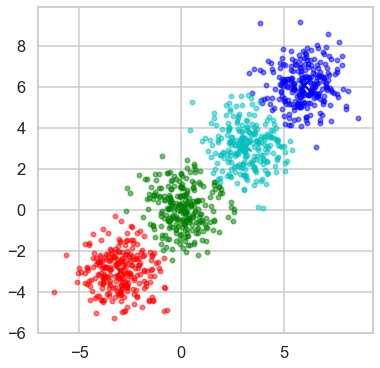

In [8]:
num_clusters = 4
km4 = KMeans(n_clusters=num_clusters)
km4.fit(X)
display_cluster(X, km4, num_clusters)

Bir de 7 cluster oluşacak şekilde aynı işlemi tekrarlayalım.

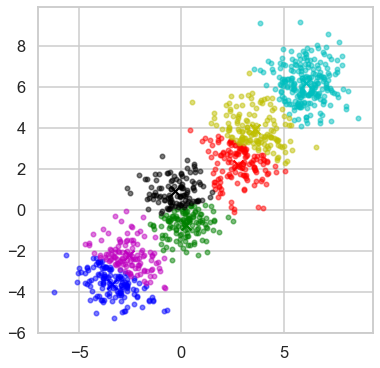

In [9]:
num_clusters = 7
km7 = KMeans(n_clusters=num_clusters)
km7.fit(X)
display_cluster(X, km7, num_clusters)

> **SORU:** Kararınızda bir değişiklik var mı?

Böyle bir örnekte muhtemelen herkes, **4 clusterın 7 clusterdan daha iyi bir seçenek** olduğunu düşünmüştür. Bunun nedeni, verileri 2D uzayda kolayca görüntüleyebilmemizdir. 

Ancak, gerçek dünya verileri genellikle 2'den çok daha fazla boyutlara sahiptir. Daha yüksek boyutlu uzaya sahip bir veri kümesini ise bu örnekte yaptığımız gibi görselleştirmek zordur. Ayrıca muhtemelen karar vermesi de bir o kadar zor olacaktır.

Ama biz neyse ki, bu tarz durumlarda bize yardımcı olması için **inertia** değerinden yararlanabileceğimi görmüştük. Bakalım inertia değerinden elde ettiğimiz sonuçlar da bizim bulgularımızla örtüşüyor mu? 

In [10]:
print('4 Cluster Inertia:', km4.inertia_)
print('7 Cluster Inertia:', km7.inertia_)

4 Cluster Inertia: 1880.1744022775633
7 Cluster Inertia: 1348.7484213780963


Doğal olarak 7 clusterdan oluşan modelimizin inertia değeri daha küçük geldi. Ama hatırlarsanız, optimum cluster sayısını belirlerken asıl dikkat etmemiz gereken **dirsek değerini** bulabilmekti.

Hemen bir görsel yardımıyla örneğimizdeki duruma bir bakalım.

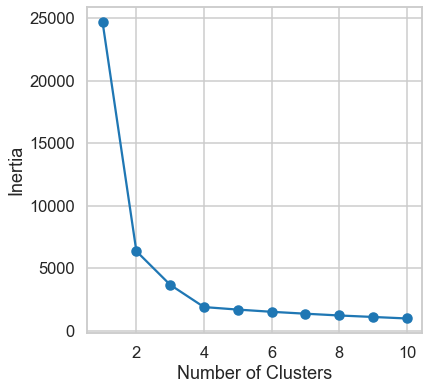

In [11]:
inertia = []
list_num_clusters = list(range(1,11))
for num_clusters in list_num_clusters:
    km = KMeans(n_clusters=num_clusters)
    km.fit(X)
    inertia.append(km.inertia_)
    
plt.plot(list_num_clusters, inertia)
plt.scatter(list_num_clusters, inertia)
plt.xlabel('Number of Clusters')
plt.ylabel('Inertia');

> **SORU:** Dirsek yöntemine göre en uygun cluster sayısı kaç olarak gözüküyor?

## 4. Görseller Üzerinden Clustering Çözümleri

Clustering problemleri sadece sayısal ve sözel veriler üzerinde uygulanan yöntemler değildir. Genellikle görseller üzerinde de oldukça başarılı çalışırlar. O zaman, bir de görsel örneği görelim.

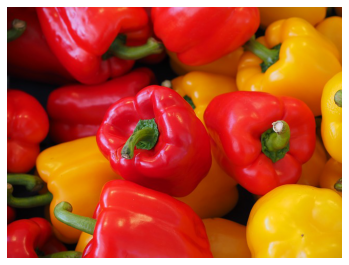

In [12]:
img = plt.imread('peppers.jpg') # Resim okuma
plt.imshow(img) # Resmi ekrana çıktı olarak basma
plt.axis('off'); # Eksenleri kapatma

In [13]:
img.shape

(480, 640, 3)

Yukarıdaki resim 480 piksel yüksekliğinde ve 640 piksel genişliğindedir. Her pikselin ne kadar kırmızı, yeşil ve mavi olduğunu gösteren 3 değeri vardır. Aşağıda farklı renkler oluşturmak için farklı RGB kombinasyonları deneyebilirsiniz. Burada toplamda $256^3 = 16.777.216$ benzersiz renk olasılıktan söz ediyoruz.

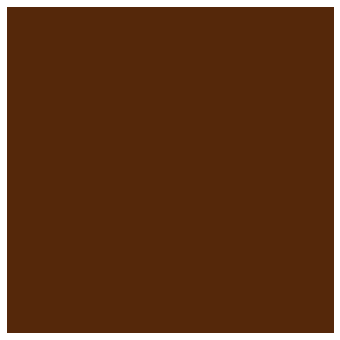

In [14]:
R = 85 # Kırmızı (min:0, max:255)
G = 40 # Yeşil (min:0, max:255)
B = 10 # Mavi (min:0, max:255)

plt.imshow([[np.array([R,G,B]).astype('uint8')]])
plt.axis('off');

Yukarıdaki biber resmimizdeki renklere ilişkin sayısal değerleri daha net görebilmek için `reshape()` fonksiyonunu kullanalım.

In [15]:
img_flat = img.reshape(img.shape[0]*img.shape[1],3)
img_flat[:5,:] # Sırasıyla (R,G,B)

array([[15, 18, 25],
       [26, 16, 24],
       [42, 15, 22],
       [65, 16, 22],
       [85, 14, 22]], dtype=uint8)

Resmimiz 480x640 pikselden oluştuğu için bu bizim için tam olarak **307,200** satıra karşılık geliyor! 

In [16]:
img_flat.shape

(307200, 3)

Hadi, K-Means algoritmamızı kullanarak bu kadar fazla renk kombinasyonunu **8 clustera** ayırmaya çalışalım.

In [17]:
kmeans = KMeans(n_clusters=8, random_state=0).fit(img_flat)

Ve her bir satırı cluster merkezlerine göre kümeleyelim.

In [18]:
img_flat2 = img_flat.copy()

for i in np.unique(kmeans.labels_):
    img_flat2[kmeans.labels_==i,:] = kmeans.cluster_centers_[i]

Son olarak da resmimizi tekrar görebilmek için **307,200 x 3** görsel yapısını **480 x 640 x 3** olarak değiştirelim. İşte karşımızda resmimizin 8 clustera bölünmüş hali :)

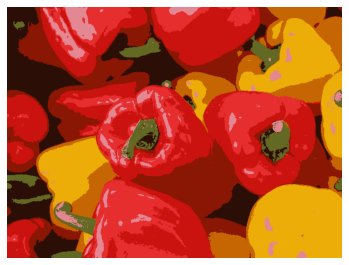

In [19]:
img2 = img_flat2.reshape(img.shape)

plt.imshow(img2)
plt.axis('off');

Son olarak ise hem clustering işlemimiz sonucunda karşımıza çıkan inertia değerlerine bakarak optimum cluster sayımızı belirleyelim hem de her bir cluster sayısının karşımıza nasıl resimler çıkardığını inceleyelim.

In [20]:
def image_cluster(img, k):
    img_flat = img.reshape(img.shape[0]*img.shape[1],3)
    kmeans = KMeans(n_clusters=k, random_state=0).fit(img_flat)
    img_flat2 = img_flat.copy()

    for i in np.unique(kmeans.labels_):
        img_flat2[kmeans.labels_==i,:] = kmeans.cluster_centers_[i]
        
    img2 = img_flat2.reshape(img.shape)

    return img2, kmeans.inertia_

2'den 15'e kadar olan clusterlarımızda elde ettiğimiz inertia değerlerimizdeki değişime bakalım.

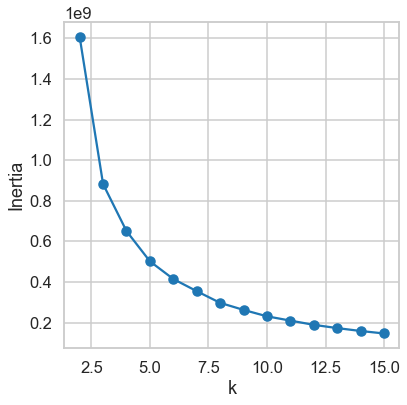

In [21]:
k_vals = list(range(2,16))
img_list = []
inertia = []
for k in k_vals:
    img2, ine = image_cluster(img, k)
    img_list.append(img2)
    inertia.append(ine)  

plt.plot(k_vals, inertia)
plt.scatter(k_vals, inertia)
plt.xlabel('k')
plt.ylabel('Inertia');

> **SORU:** Burada en optimum cluster sayımız kaç olarak gözüküyor?

Her zaman dirsek yönteminden tam istediğimiz çıktılara ulaşamayabiliriz. Dirsek yöntemine alternatif olarak [silhouette coefficient](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.silhouette_score.html) yöntemini de inceleyebilirsiniz.

Son olarak da elde etmiş olduğumuz görsel çıktılara kıyaslayalım :)

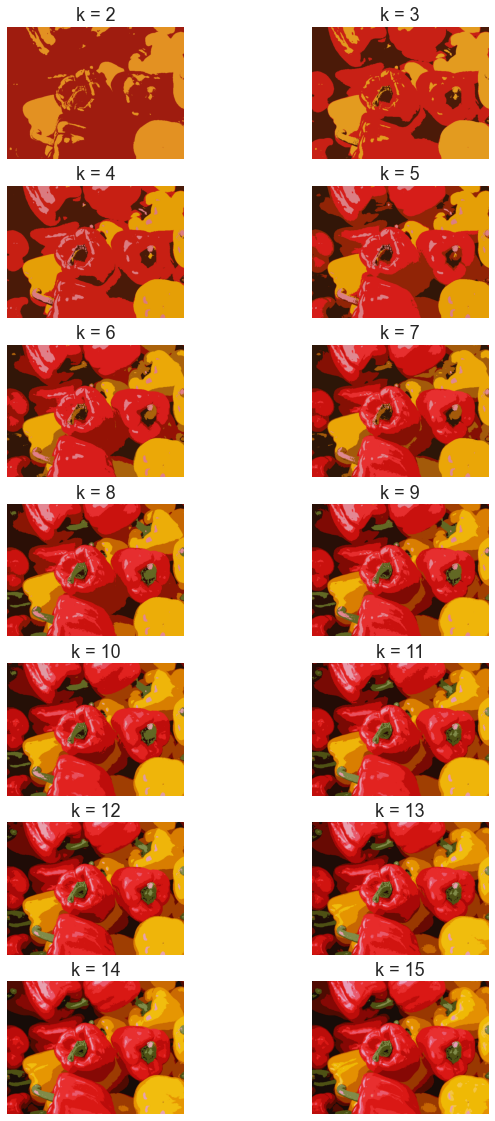

In [22]:
plt.figure(figsize=[10,20])
for i in range(len(k_vals)):
    plt.subplot(7,2,i+1)
    plt.imshow(img_list[i])
    plt.title('k = '+ str(k_vals[i]))
    plt.axis('off');